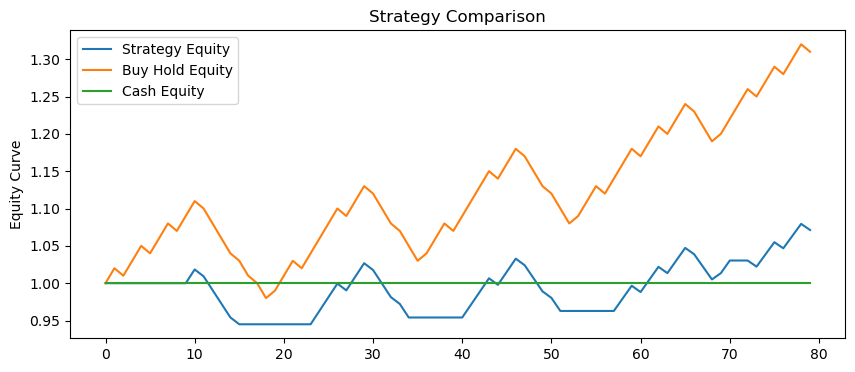

,Prices,Return,Fast_MA,Slow_MA,Signal,Strategy_Return,Strategy_Equity,Running_Max_Strategy,Drawdown_Strategy,Buy_Hold_Return,Buy_Hold_Equity,Buy_Hold_Running_Max,Buy_Hold_Drawdown,Cash_Equity
0,100,NaN,NaN,NaN,0,0.000000,1.000000,1.000000,0.000000,0.000000,1.00,1.00,0.000000,1
1,102,0.020000,NaN,NaN,0,0.000000,1.000000,1.000000,0.000000,0.020000,1.02,1.02,0.000000,1
2,101,-0.009804,NaN,NaN,0,-0.000000,1.000000,1.000000,0.000000,-0.009804,1.01,1.02,-0.009804,1
3,103,0.019802,NaN,NaN,0,0.000000,1.000000,1.000000,0.000000,0.019802,1.03,1.03,0.000000,1
4,105,0.019417,102.2,NaN,0,0.000000,1.000000,1.000000,0.000000,0.019417,1.05,1.05,0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,129,0.015748,126.2,123.6,1,0.015748,1.054890,1.054890,0.000000,0.015748,1.29,1.29,0.000000,1
76,128,-0.007752,127.0,124.1,1,-0.007752,1.046712,1.054890,-0.007752,-0.007752,1.28,1.29,-0.007752,1
77,130,0.015625,127.8,125.0,1,0.015625,1.063067,1.063067,0.000000,0.015625,1.30,1.30,0.000000,1
78,132,0.015385,129.2,126.3,1,0.015385,1.079422,1.079422,0.000000,0.015385,1.32,1.32,0.000000,1


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = [100, 102, 101, 103, 105, 104, 106, 108, 107, 109,
111, 110, 108, 106, 104, 103, 101, 100, 98, 99,
101, 103, 102, 104, 106, 108, 110, 109, 111, 113,
112, 110, 108, 107, 105, 103, 104, 106, 108, 107,
109, 111, 113, 115, 114, 116, 118, 117, 115, 113,
112, 110, 108, 109, 111, 113, 112, 114, 116, 118,
117, 119, 121, 120, 122, 124, 123, 121, 119, 120,
122, 124, 126, 125, 127, 129, 128, 130, 132, 131]

fast_window = 5
slow_window = 10

df = pd.DataFrame({'Prices' : data})
df['Return'] = df['Prices'].pct_change()
df['Fast_MA'] = df['Prices'].rolling(window = fast_window).mean()
df['Slow_MA'] = df['Prices'].rolling(window = slow_window).mean()
df['Signal'] = np.where(df['Fast_MA'] > df['Slow_MA'],1,0)
df['Strategy_Return'] = df['Return'] * df['Signal'].shift(1)
df['Strategy_Return'] = df['Strategy_Return'].fillna(0)
df['Strategy_Equity'] = (1 + df['Strategy_Return']).cumprod()
df['Running_Max_Strategy'] = df['Strategy_Equity'].cummax()
df['Drawdown_Strategy'] = (df['Strategy_Equity'] -df['Running_Max_Strategy'] )/df['Running_Max_Strategy'] 
Max_Drawdown_Strategy = df['Drawdown_Strategy'].min() 

df['Buy_Hold_Return'] = df['Return']
df['Buy_Hold_Return'] = df['Buy_Hold_Return'].fillna(0)
df['Buy_Hold_Equity'] = ( 1 + df['Buy_Hold_Return']).cumprod()
df['Buy_Hold_Running_Max'] = df['Buy_Hold_Equity'].cummax()
df['Buy_Hold_Drawdown'] = (df['Buy_Hold_Equity'] - df['Buy_Hold_Running_Max'])/df['Buy_Hold_Running_Max']
Max_Buy_Hold_Drawdown = df['Buy_Hold_Drawdown'].min()

df['Cash_Equity'] = 1

Strategy_Final_Equity =  df['Strategy_Equity'].iloc[-1]
Buy_Hold_Final_Equity = df['Buy_Hold_Equity'].iloc[-1]
Cash_Final_Equity = df['Cash_Equity'].iloc[-1]



plt.figure(figsize = (10,4))

plt.plot(df['Strategy_Equity'] , label = 'Strategy Equity')
plt.plot(df['Buy_Hold_Equity'] ,label = 'Buy Hold Equity')
plt.plot(df['Cash_Equity'] , label = 'Cash Equity')


plt.title('Strategy Comparison')
plt.ylabel('Equity Curve')

plt.legend()
plt.show()


df

## Observations

#1. The strategy did not beat buy-and-hold in terms of final equity.
#2. Drawdown comparison was calculated separately because it was not clearly visible from the equity curve graph.
#3. Staying in cash was worse because both strategy and buy-and-hold ended above 1.
#4. The strategy was profitable, but it is not clearly better than buy-and-hold unless it reduces drawdown or risk meaningfully.
#5. This comparison is limited because the dataset is small, transaction costs are not included, and no train/test validation is done.
